In [1]:
import numpy as np
from skimage.morphology import skeletonize
import importlib
import porespy_compat
importlib.reload(porespy_compat)
from porespy_compat import prepare_matplotlib, import_porespy
prepare_matplotlib()
ps = import_porespy()
from matplotlib import pyplot as plt
import tifffile as tif
import cv2
import scipy.ndimage as ndi
from skimage import measure
from skimage import morphology as mph
from skimage.color import label2rgb
import pandas as pd
from pathlib import Path




In [2]:
def find_intersectikon(skeleton):
    selems = list()
    selems.append(np.array([[0, 1, 0], [1, 1, 1], [0, 0, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [1, 0, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [0, 1, 0]]))
    selems.append(np.array([[0, 1, 0], [1, 1, 0], [0, 0, 1]]))
    selems.append(np.array([[0, 0, 1], [1, 1, 1], [0, 1, 0]]))
    selems = [np.rot90(selems[i], k=j) for i in range(5) for j in range(4)]
    selems.append(np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]]))
    selems.append(np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]]))
    branches = np.zeros_like(skeleton, dtype=bool)
    for selem in selems:
        branches |= ndi.binary_hit_or_miss(skeleton, selem)
    return branches

In [3]:
def crack_skeletonize(crack):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(50,50))
    dilated= cv2.dilate(crack,kernel,iterations=1)
    ske=skeletonize(np.where(dilated!=0,1,0))
    return ske

In [4]:
def get_indecrack(ske,branches):
    kernel_j = cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
    bra=cv2.dilate(branches.astype('uint8'),kernel_j)
    cracksonly=np.where(ske!=0,255,0)
    cracksonly=np.where(bra!=0,0,cracksonly)
    return cracksonly

In [5]:
def meausure_thickness(img,reso=9):
    thk=ps.filters.local_thickness(img,sizes=np.arange(0,60,1))
    thk=thk*reso
    psd=ps.metrics.pore_size_distribution(thk,voxel_size=reso,log=False)
    return thk,psd

In [6]:
def measure_length(skelet,reso=9):
    length_label=measure.label(skelet)
    prop_table=measure.regionprops_table(length_label, properties=('label','centroid','area'))
    prop_table['area']=prop_table['area']*reso
    prop = measure.regionprops(length_label)
    im_length=reso*np.array(props_to_image(prop, length_label.shape, 'area'))
    return prop_table,im_length

In [7]:
def denoise_skeletonize(crack):
    crack=np.where(crack!=0,1,0)
    crack=crack.astype('uint8')
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(10,10))
    dilated= cv2.dilate(crack,kernel,iterations=1)
    eroded=cv2.erode(dilated,kernel,iterations=1)
    ske=(skeletonize(np.where(dilated!=0,1,0))).astype('uint8')
    return (255*ske)

In [8]:
""""
properties to image
"""""
import porespy as ps
def props_to_image(regionprops, shape, prop):
    im = np.zeros(shape=shape)
    for r in regionprops:
        if prop == 'convex':
            mask = r.convex_image
        else:
            mask = r.image
        temp = mask * r[prop]
        s = ps.tools.bbox_to_slices(r.bbox)
        im[s] += temp
    return im


In [9]:
def plot_nonzero_histogram(array_2d, bins=30, ax=None, title="Histogram of Nonzero Values"):
    array_2d = np.asarray(array_2d)
    if array_2d.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {array_2d.shape}")

    nonzero_values = array_2d[array_2d != 0]
    if nonzero_values.size == 0:
        raise ValueError("The input array does not contain any nonzero values.")

    if ax is None:
        _, ax = plt.subplots()

    ax.hist(nonzero_values.ravel(), bins=bins, color="slategray", edgecolor="black")
    ax.set_ylim(0,15)
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    return ax


Read image and parameters

L321_0_crop017
L331_2_crop019
L112_0_crop027
L303_0_crop035
L201_0_crop036
L100_1_crop002
L321_2_crop015
L123_0_crop024
L112_2_crop013
L411_1_crop019
L411_0_crop014
L213_2_crop015
L411_1_crop012
L213_0_crop010
L223_0_crop030
L201_0_crop031
L123_1_crop027
L123_0_crop005
L2b1_2_crop014
L111_2_crop006
L201_1_crop016
L2b1_2_crop009
L1311_1_crop001
L2312_0_crop024
L3322_1_crop012
L133_2_crop010
L201_1_crop027
L311_0_crop028
L133_1_crop007
L133_1_crop015
L2b2_0_crop016
L321_0_crop007
L232_2_crop016
L321_2_crop012
L332_0_crop025
L332_2_crop004
L232_0_crop020
L222_0_crop007
L311_0_crop001
L331_2_crop015
L321_2_crop025
L331_1_crop015
L231_1_crop001
L211_1_crop008
L112_0_crop023
L121_1_crop012
L211_0_crop037
L2b2_1_crop013
L304_2_crop009
L121_0_crop008
L2012_0_crop008
L303_1_crop024
L313_0_crop003
L311_1_crop005
L201_1_crop005
L133_1_crop014
L313_0_crop018
L321_2_crop023
L411_0_crop010
L121_2_crop005
L2012_2_crop005
L321_0_crop002
L1112_0_crop012
L223_0_crop016
L4322_0_crop003
L123_0_crop014
L40

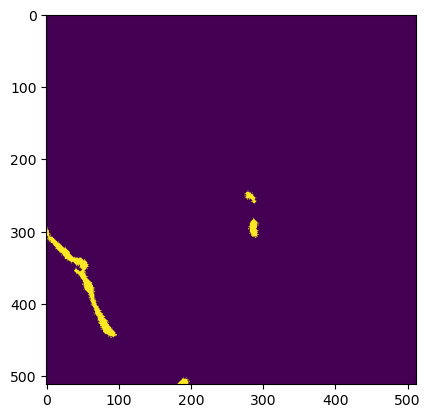

In [11]:
from PIL import Image
import math

def seg_crack(img_bi):
    red_mask=np.where(img_bi!=0,255,0)
    return red_mask

raw_img=[[[] for i in range(2)] for j in range(3)]
length_img=[[[] for i in range(2)] for j in range(3)]
length_prop=[[[] for i in range(2)] for j in range(3)]
width_img=[[[] for i in range(2)] for j in range(3)]
density=[[[] for i in range(2)] for j in range(3)]
from pathlib import Path
Raw_img_path=Path("/home/jixi/dataset/Test_conditionalUnet/crk_mask")
tif_files = [f for f in Raw_img_path.glob("*.png") if not f.name.startswith("._")]
for file in tif_files:
    #print(file)
    fname=file.stem
    print(fname)
    agg=int(fname[1])-1
    exp=fname[2]
    if exp=='b':
        exp=1
    else:
        exp=int(exp)
        exp=int(math.floor(exp/2))
    if agg>2:
        agg=2
    img_rgb=Image.open(file).convert("L")
    img_rgb=np.asarray(img_rgb).astype('uint8')
    raw_img[agg][exp].append(img_rgb)
for j in range(3):
    for i in range(2):
        for k in range(len(raw_img[j][i])):
            seg=seg_crack(raw_img[j][i][k])
            plt.imshow(seg)
            a,b=seg.shape
            crack_den=np.sum(seg)/(a*b)
            density[j][i].append(crack_den)
            thk,psd=meausure_thickness(seg)
            width_img[j][i].append(thk)
            skele=denoise_skeletonize(seg)
            table,img_l=measure_length(skele.astype('uint8'))
            length_img[j][i].append(img_l)
            length_prop[j][i].append(table)


IndexError: list index out of range

1.png
19.png
56.png
51.png
12.png
42.png
33.png
6.png
59.png
58.png
36.png
53.png
38.png
47.png
22.png
29.png
48.png
35.png
41.png
40.png
28.png
52.png
57.png
31.png
54.png
21.png
49.png
37.png
11.png
32.png
0.png
8.png
23.png
46.png
14.png
43.png
50.png
27.png
13.png
30.png
45.png
3.png
9.png
4.png
5.png
34.png
44.png
10.png
2.png
26.png
25.png
7.png
18.png
39.png
20.png
24.png
15.png
17.png
55.png
16.png


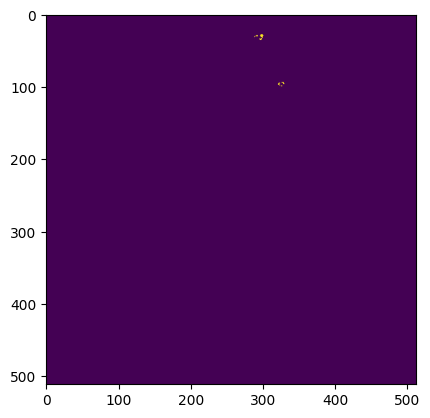

In [ ]:
#from PIL import Image
#import math
#import os
#raw_imgplain=[]
#length_imgplain=[]
#length_propplain=[]
#width_imgplain=[]
#densityplain=[]
#from pathlib import Path
#out_img_pathplain=Path("/home/jixi/project/diff_unet/diff/baseline_train/Nolabeloutput0330/Test")
#imgpath=os.listdir(out_img_pathplain)
#for i in imgpath:
#    print(i)
#    img_rgb=cv2.imread(out_img_pathplain/i)
#    raw_imgplain.append(img_rgb)
#for i in range(len(raw_imgplain)):
#    seg=seg_crack(raw_imgplain[i])
#    plt.imshow(seg)
#    a,b=seg.shape
#    crack_den=np.sum(seg)/(a*b)
#    densityplain.append(crack_den)
#    thk,psd=meausure_thickness(seg,1)
#    width_imgplain.append(thk)
#    skele=denoise_skeletonize(seg)
#    table,img_l=measure_length(skele.astype('uint8'))
#    length_imgplain.append(img_l)
#    length_propplain.append(table)

0 0 0
0 0 1
0 0 2
0 0 3
0 0 4
0 0 5
0 0 6
0 0 7
0 0 8
0 0 9
0 0 10
0 0 11
0 0 12
0 0 13
0 0 14
0 0 15
0 0 16
0 0 17
0 0 18
0 0 19
0 0 20
0 0 21
0 0 22
0 0 23
0 0 24
0 0 25
0 0 26
0 0 27
0 0 28
0 0 29
0 0 30
0 0 31
0 0 32
0 0 33
0 0 34
0 0 35
0 0 36
0 0 37
0 0 38
0 0 39
0 0 40
0 0 41
0 0 42
0 0 43
0 0 44
0 0 45
0 0 46
0 0 47
0 0 48
0 0 49
0 0 50
0 0 51
0 0 52
0 0 53
0 0 54
0 0 55
0 0 56
0 0 57
0 0 58
0 0 59
0 0 60
0 0 61
0 0 62
0 0 63
0 0 64
0 0 65
0 0 66
0 0 67
0 0 68
0 0 69
0 0 70
0 0 71
0 0 72
0 0 73
0 0 74
0 0 75
0 0 76
0 0 77
0 0 78
0 0 79
0 0 80
0 0 81
0 0 82
0 0 83
0 0 84
0 0 85
0 0 86
0 0 87
0 0 88
0 0 89
0 0 90
0 0 91
0 0 92
0 0 93
0 0 94
0 0 95
0 0 96
0 0 97
0 0 98
0 0 99
0 0 100
0 0 101
0 0 102
0 0 103
0 0 104
0 0 105
0 0 106
0 0 107
0 0 108
0 0 109
0 0 110
0 0 111
0 0 112
0 0 113
0 0 114
0 0 115
0 0 116
0 0 117
0 0 118
0 0 119
0 0 120
0 0 121
0 0 122
0 0 123
0 0 124
0 0 125
0 0 126
0 0 127
0 0 128
0 0 129
0 0 130
0 0 131
0 0 132
0 0 133
0 0 134
0 0 135
0 0 136
0 0 137
0 0 13

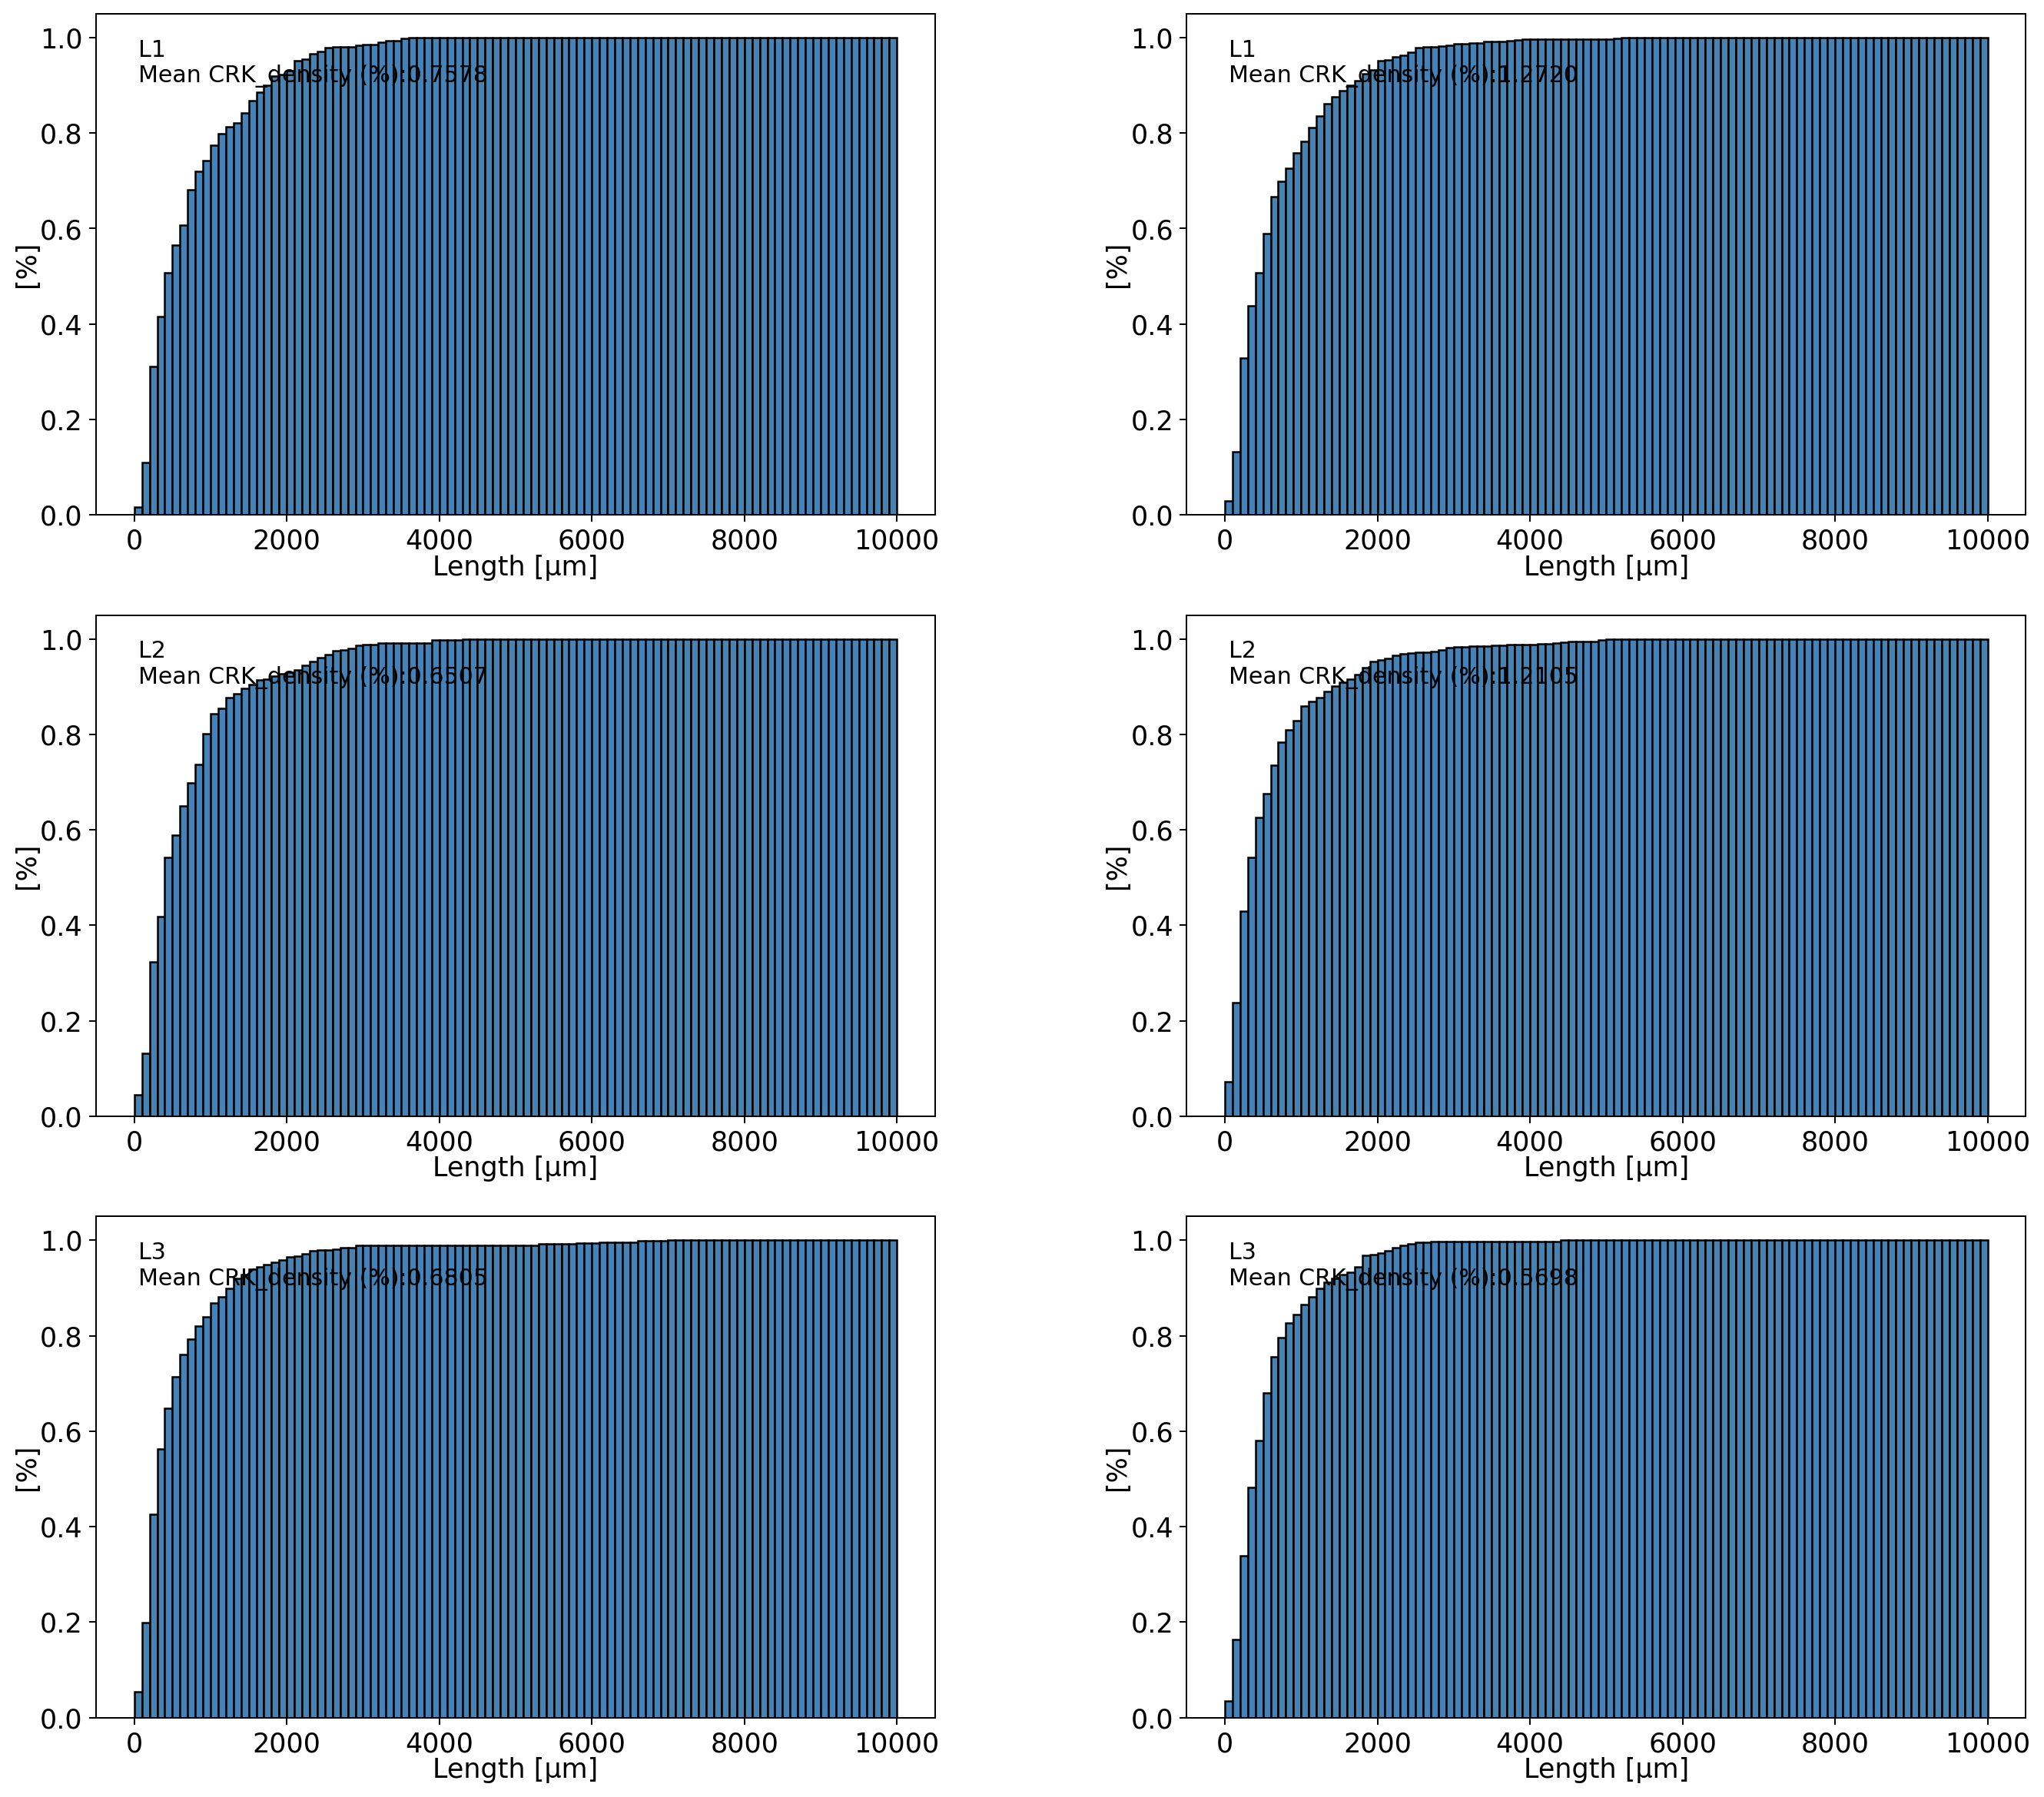

In [14]:
#Count width (Group average)
out_img_path=Path("/home/jixi/project/genai/output_conditional_unet_agg_mask/Evaluation_generation")
plt.rcParams['font.size']=14
fig,ax1=plt.subplots(ncols=2,nrows=3,figsize=(15,16),dpi=180)
for i in range(3):
    for j in range(2):
        group_w=np.array([])
        means=[]
        for k in range(len(width_img[i][j])):
            print(i,j,k)
            nonzero_values = width_img[i][j][k][width_img[i][j][k]!= 0]
            group_w=np.concatenate([group_w,nonzero_values.ravel()])
            means.append(density[i][j][k])
        weights = np.ones_like(group_w) / len(group_w)*100
        ax1[i][j].hist(group_w, bins=np.arange(0,610,10),
                       weights=weights,
                       cumulative=True,
                       density=True,
                       color="steelblue", edgecolor="black")
        mean_v=np.mean(np.array(means))
        ax1[i][j].text(0.05, 0.95, f"L{i+1}\nMean CRK_density (%):{mean_v/255*100:.4f}", transform=ax1[i][j].transAxes, fontsize=12, verticalalignment='top')
        #ax1[i][j].set_xlim(0,400)
        #ax1[i][j].set_ylim(0,30)
        ax1[i][j].set_xlabel("Width [\u03bcm]",labelpad=0)
        ax1[i][j].set_ylabel("[%]",labelpad=0)
plt.subplots_adjust(wspace=0.3, hspace=0.2)
plt.savefig(out_img_path/'RawWidth.png',bbox_inches='tight')
plt.close("all")
plt.rcParams['font.size']=14
#Count width (Group average)
#Count width (Group average)
fig,ax1=plt.subplots(ncols=2,nrows=3,figsize=(18,16),dpi=180)
for i in range(3):
    for j in range(2):
        group_l=np.array([])
        means=[]
        for k in range(len(length_img[i][j])):
            #nonzero_values = length_img[i][j][k][length_img[i][j][k]!= 0]
            #group_l=np.concatenate([group_l,nonzero_values.ravel()])
            means.append(density[i][j][k])
            area_vals = np.asarray(length_prop[i][j][k]["area"])
            group_l=np.concatenate([group_l,area_vals])
        weights = np.ones_like(group_l) / len(group_l)*100
        ax1[i][j].hist(group_l, bins=np.arange(0,10100,100),
                       weights=weights,
                       cumulative=True,
                       density=True,
                       color="steelblue", edgecolor="black")
        mean_v=np.mean(np.array(means))
        ax1[i][j].text(0.05, 0.95, f"L{i+1}\nMean CRK_density (%):{mean_v/255*100:.4f}", transform=ax1[i][j].transAxes, fontsize=12, verticalalignment='top')
        #ax1[i][j].set_xlim(0,8000)
        #ax1[i][j].set_ylim(0,30)
        ax1[i][j].set_xlabel("Length [\u03bcm]",labelpad=0)
        ax1[i][j].set_ylabel("[%]",labelpad=0)
plt.subplots_adjust(wspace=0.3, hspace=0.2)
plt.savefig(out_img_path/'RawLength.png',bbox_inches='tight')    

In [64]:
#Count length width
for i in range(len(records)):
    fig,ax1=plt.subplots(ncols=7,nrows=4,figsize=(18,16),dpi=180)
    for j in range(len(records[i])):
        for k in range(len(records[i][j])):
            nonzero_values = width[i][j][k][width[i][j][k] != 0]
            if nonzero_values.size == 0:
                continue
            else:
                print(j,k)
                print(records[i][j][k]["image_name"])
                
                ax1[j][k].hist(nonzero_values.ravel(), bins=np.arange(0,60), color="slategray", edgecolor="black")
                ax1[j][k].set_title(f"{records[i][j][k]["image_name"][:4]}\nCRK_den:{density[i][j][k]:.4f}",fontsize=10)
                ax1[j][k].set_xlim(0,30)
                ax1[j][k].set_ylim(0,4000)
    plt.savefig(f"Width_L{i+1}.png",bbox_inches='tight')
#Count width
for i in range(len(records)):
    fig,ax1=plt.subplots(ncols=7,nrows=4,figsize=(18,16),dpi=180)
    for j in range(len(records[i])):
        for k in range(len(records[i][j])):
            nonzero_values = length[i][j][k][length[i][j][k] != 0]
            if nonzero_values.size == 0:
                continue
            else:
                print(j,k)
                print(records[i][j][k]["image_name"])
                
                ax1[j][k].hist(nonzero_values.ravel(), bins=np.arange(0,500), color="slategray", edgecolor="black")
                ax1[j][k].set_title(f"{records[i][j][k]["image_name"][:4]}\nCRK_den:{density[i][j][k]:.4f}",fontsize=10)
                #ax1[j][k].set_xlim(0,30)
                ax1[j][k].set_ylim(0,4000)
    plt.savefig(f"Length_L{i+1}.png",bbox_inches='tight')
        

SyntaxError: f-string: unmatched '[' (3290397138.py, line 14)

[ 26.  20.  44.  43. 139. 106.  23.  14.  26.  36. 122.  16.  33.  17.
  31.  48.  25.  17.  19.   7.  10.  74.  18.  65.  39.  74.  23.  62.
   6.  16.  15.  11. 104.  24.  17.  29.  35.  16.  23.  10.  35.  50.
  83. 108.  16.   7.  51.  51.  11. 171.  17.  10.  47.  28.  22. 144.
   5.  67.  16.   6.   9.  57.   6.  17.  66.   8.  17. 193.  57.  95.
  18.   9.  18.   8.  48. 100. 130.  97. 225.  23.  34.  22.  49.  18.
  38.  20. 114.  14.  27.  42.  27.  41. 142.  57.  24.   9. 125.  12.
  68.  81.  63.   7.  45.  40.  49.  79.  59.  97.  13.  25.  57.  11.
   5.   8.  22.  36.  16. 262.  21.  17. 182. 148.   4. 106.  13.  17.
  37. 137.  18. 110.   5.  39.  36.  20.  34.  12.  24.  28.  61. 153.
   8.  91.  73.  42.  26.  61.  31.   7.  45.  74. 209.  34.  47.  42.
  33.  90.   3.  19.  38.  41.  16.  10.  68.  30.  30.  19.  16.  11.]


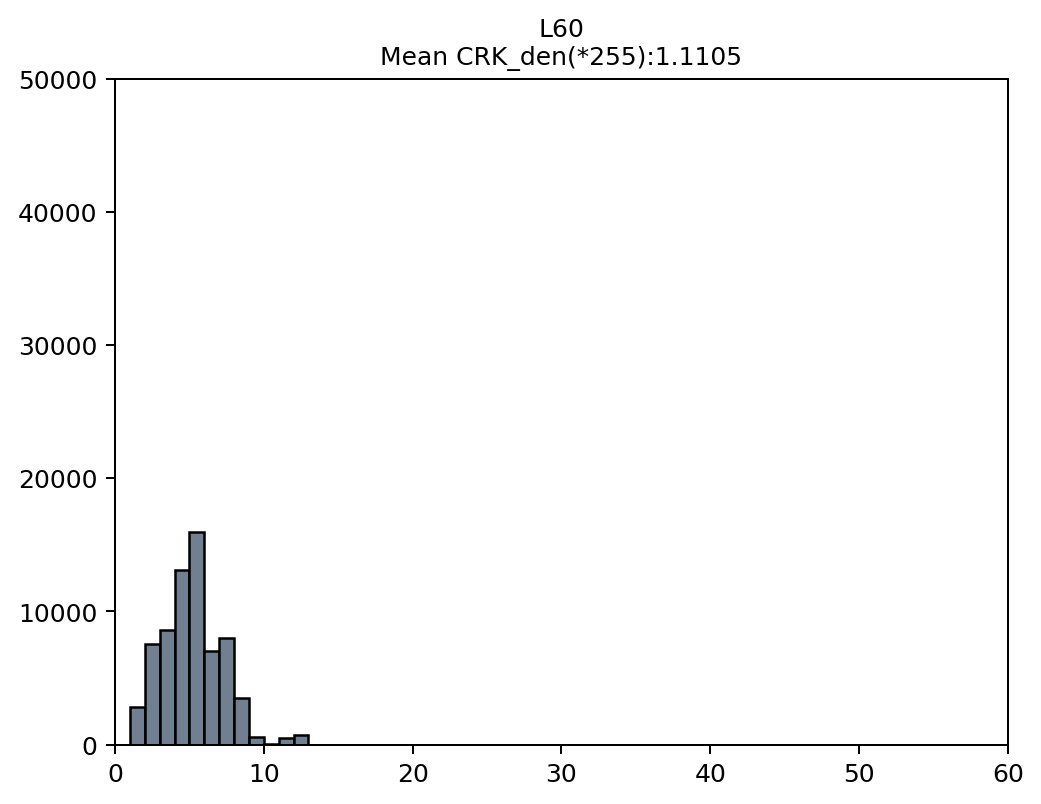

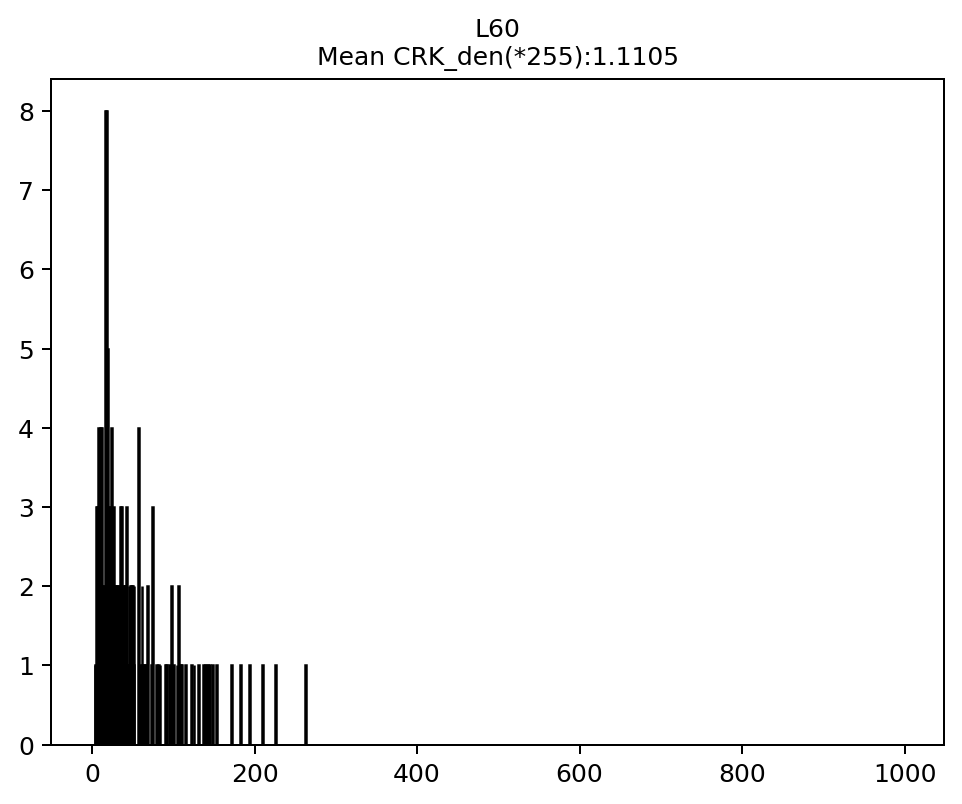

In [29]:
#Count width (Group average)
fig,ax1=plt.subplots(dpi=180)
means=[]
group_wplain=np.array([])
for i in range(len(width_imgplain)):
    nonzero_values = width_imgplain[i][width_imgplain[i]!= 0]
    group_wplain=np.concatenate([group_wplain,nonzero_values.ravel()])
    means.append(densityplain[i])
ax1.hist(group_wplain, bins=np.arange(0,60,1),color="slategray", edgecolor="black")
mean_v=np.mean(np.array(means))
ax1.set_title(f"L{i+1}\nMean CRK_den(*255):{mean_v:.4f}",fontsize=10)
ax1.set_xlim(0,60)
ax1.set_ylim(0,50000)
plt.savefig('Widthplain_smallset18_gen.png',bbox_inches='tight')
#Count width (Group average)
#Count width (Group average)
fig,ax1=plt.subplots(dpi=180)
means=[]
group_lplain=np.array([])

for k in range(len(length_imgplain)):
    #nonzero_values = length_img[i][j][k][length_img[i][j][k]!= 0]
    #group_l=np.concatenate([group_l,nonzero_values.ravel()])
    means.append(densityplain[k])
    area_vals = np.asarray(length_propplain[k]["area"])
    group_lplain=np.concatenate([group_lplain,area_vals])
print(group_lplain)
ax1.hist(group_lplain, bins=np.arange(0,1000,1), color="slategray", edgecolor="black")
mean_v=np.mean(np.array(means))
ax1.set_title(f"L{i+1}\nMean CRK_den(*255):{mean_v:.4f}",fontsize=10)
#ax1.set_xlim(0,1000)
#ax1.set_ylim(0,20)
plt.savefig('Lengthplain_smallset18_gen.png',bbox_inches='tight')    

Measure the thickness and distribution of cracks after manual segmentation

In [ ]:
resolution=20
thk,psd=meausure_thickness(im,resolution)   # input resolution in um/px
width_s=np.array(thk)*resolution
crack_area=np.count_nonzero(im)*(resolution**2)/1000000

  0%|          | 0/60 [00:00<?, ?it/s]

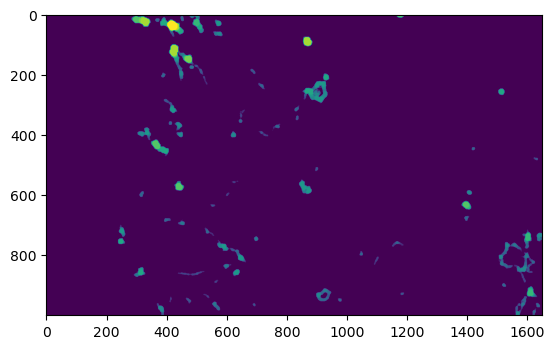

In [ ]:
plt.imshow(thk)

<BarContainer object of 10 artists>

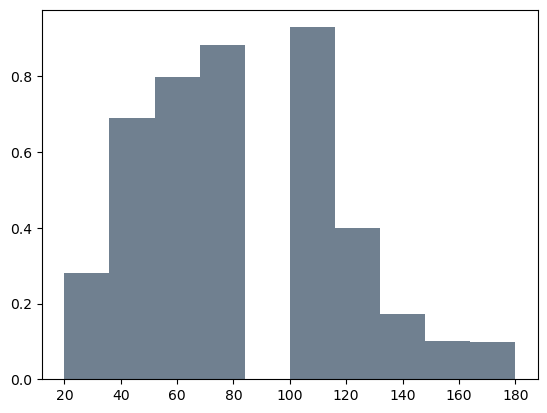

In [ ]:

plt.bar(psd.bin_centers,(np.array(psd.satn)*crack_area),psd.bin_widths,color='slategray')

In [61]:
"""""
plot length distribution
"""
skele=denoise_skeletonize(im)
table,img_l=measure_length(skele.astype('uint8'))
length__true=np.array(img_l*resolution)


Text(0.5, 0, 'length(um)')

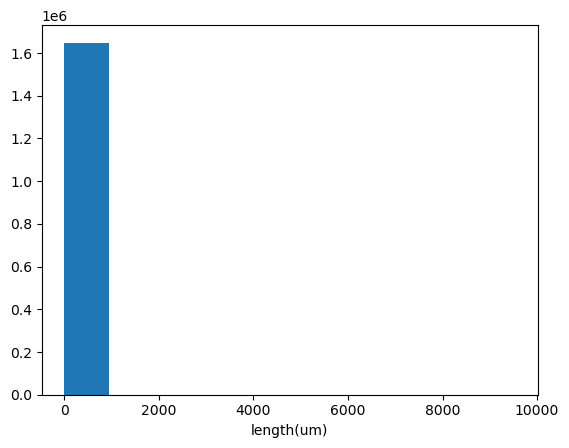

In [65]:
plt.hist(length__true.flatten())
plt.xlabel('length(um)')